In [ ]:
import sys
import types
import tensorflow as tf
import numpy as np
import scipy
import h5py
import os
import cv2

!pip install git+https://github.com/rcmalli/keras-vggface.git -q
!pip install keras_applications -q
!pip install opencv-python-headless -q

print(f"Versões carregadas:")
print(f" - Numpy: {np.__version__} (Deve ser < 2.0, ideal 1.24.x)")
print(f" - Scipy: {scipy.__version__} (Ideal 1.10.x)")
print(f" - h5py:  {h5py.__version__}  (Deve ser < 3.10)")

import keras.utils
from keras.layers import Conv2D, BatchNormalization

if not hasattr(keras.utils, 'layer_utils'):
    layer_utils = types.ModuleType('layer_utils')
    layer_utils.get_source_inputs = tf.keras.utils.get_source_inputs
    keras.utils.layer_utils = layer_utils
    sys.modules['keras.utils.layer_utils'] = layer_utils

if not hasattr(keras.utils, 'data_utils'):
    data_utils = types.ModuleType('data_utils')
    data_utils.get_file = tf.keras.utils.get_file
    keras.utils.data_utils = data_utils
    sys.modules['keras.utils.data_utils'] = data_utils

if not hasattr(Conv2D, '_is_patched'):
    _original_conv2d_init = Conv2D.__init__
    _original_bn_init = BatchNormalization.__init__

    def patched_conv2d_init(self, *args, **kwargs):
        if 'name' in kwargs and kwargs['name'] is not None:
            kwargs['name'] = kwargs['name'].replace('/', '_')
        _original_conv2d_init(self, *args, **kwargs)

    def patched_bn_init(self, *args, **kwargs):
        if 'name' in kwargs and kwargs['name'] is not None:
            kwargs['name'] = kwargs['name'].replace('/', '_')
        _original_bn_init(self, *args, **kwargs)

    Conv2D.__init__ = patched_conv2d_init
    BatchNormalization.__init__ = patched_bn_init
    Conv2D._is_patched = True

print("\nAmbiente blindado. Pode prosseguir com a Célula 2 (Arquitetura).")

2025-12-02 22:49:54.090362: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764715794.288971      46 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764715794.347305      46 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 86.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D, Reshape, multiply, Concatenate, Add, Activation, Lambda
from keras_vggface.vggface import VGGFace

MODEL_WEIGHTS_PATH = '/kaggle/input/cbam-resnet50-vggface-fer2013/model_cbam_finetuned.h5' 

def cbam_block(cbam_feature, ratio=8):
    """Bloco CBAM com correções para TF 2.x"""
    channel_axis = -1
    channel = cbam_feature.shape[channel_axis]
    
    shared_layer_one = Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_layer_two = Dense(channel, kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    
    avg_pool = GlobalAveragePooling2D()(cbam_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_layer_two(shared_layer_one(avg_pool))
    
    max_pool = GlobalAveragePooling2D()(cbam_feature)
    max_pool = Reshape((1, 1, channel))(max_pool)
    max_pool = shared_layer_two(shared_layer_one(max_pool))
    
    cbam_channel = Activation('sigmoid')(Add()([avg_pool, max_pool]))
    channel_refined_feature = multiply([cbam_feature, cbam_channel])
    
    avg_pool_spatial = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(channel_refined_feature)
    max_pool_spatial = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(channel_refined_feature)
    
    concat = Concatenate(axis=3)([avg_pool_spatial, max_pool_spatial])
    cbam_spatial = Conv2D(filters=1, kernel_size=(7, 7), strides=1, padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False, name='spatial_attention_map')(concat)
    
    return multiply([channel_refined_feature, cbam_spatial])

print("Construindo modelo...")
tf.keras.backend.clear_session()

vggface_base = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3), pooling=None)
last_layer = vggface_base.output
if len(last_layer.shape) == 4 and last_layer.shape[1] == 1:
    last_layer = vggface_base.layers[-2].output

def deprocess_input_vggface(x):
    """Reverte o pré-processamento do VGGFace para visualização."""
    x_temp = x.copy()
    if len(x_temp.shape) == 4 and x_temp.shape[0] == 1:
        x_temp = x_temp[0, ...]
    x_temp[..., 0] += 91.4953
    x_temp[..., 1] += 103.8827
    x_temp[..., 2] += 131.0912

attention_output = cbam_block(last_layer)
x = Flatten()(attention_output)
x = Dropout(0.25)(x)
x = Dense(2048, activation='relu')(x)
x = Dropout(0.25)(x)
x = Dense(1024, activation='relu')(x)
outputs = Dense(8, name='classifer')(x)

model = Model(inputs=vggface_base.input, outputs=outputs)

if os.path.exists(MODEL_WEIGHTS_PATH):
    model.load_weights(MODEL_WEIGHTS_PATH)
    print("Pesos carregados com sucesso!")
else:
    print(f"ALERTA: Arquivo de pesos '{MODEL_WEIGHTS_PATH}' não encontrado. O modelo está com pesos aleatórios/ImageNet.")

Construindo modelo...


2025-12-02 22:51:18.385952: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


94694792/94694792 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Pesos carregados com sucesso!


In [ ]:
import glob
from tqdm.notebook import tqdm

TEST_DIR = '/kaggle/input/fer2013plus/fer2013plus/fer2013/test'

class_indices = {
    'neutral': 0, 'happiness': 1, 'surprise': 2, 'sadness': 3,
    'anger': 4, 'disgust': 5, 'fear': 6, 'contempt': 7
}

emotion_dict = {v: k for k, v in class_indices.items()}

print(f"Lendo imagens de: {TEST_DIR}")
print(f"Mapeamento de classes esperado: {class_indices}")

x_test = []
y_test_indices = []
filepaths = []

for label_name, label_idx in class_indices.items():
    folder_path = os.path.join(TEST_DIR, label_name)
    if not os.path.exists(folder_path):
        print(f"Aviso: Pasta '{label_name}' não encontrada.")
        continue
        
    images = glob.glob(os.path.join(folder_path, '*.png'))
    print(f"  - Carregando {label_name}: {len(images)} imagens")
    
    for img_path in images:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (48, 48))
            x_test.append(img)
            y_test_indices.append(label_idx)
            filepaths.append(img_path)

x_test = np.array(x_test)
y_test = tf.keras.utils.to_categorical(y_test_indices, num_classes=8)

print(f"\nDados Carregados: x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

Lendo imagens de: /kaggle/input/fer2013plus/fer2013plus/fer2013/test
Mapeamento de classes esperado: {'neutral': 0, 'happiness': 1, 'surprise': 2, 'sadness': 3, 'anger': 4, 'disgust': 5, 'fear': 6, 'contempt': 7}
  - Carregando neutral: 2597 imagens
  - Carregando happiness: 1827 imagens
  - Carregando surprise: 900 imagens
  - Carregando sadness: 856 imagens
  - Carregando anger: 644 imagens
  - Carregando disgust: 57 imagens
  - Carregando fear: 167 imagens
  - Carregando contempt: 51 imagens

Dados Carregados: x_test shape: (7099, 48, 48), y_test shape: (7099, 8)


Iniciando avaliação para 4 imagens de 'anger' com confiança > 80%...
Imagem selecionada: 6180 (Conf: 90.24%)
Imagem selecionada: 6181 (Conf: 99.99%)
Imagem selecionada: 6183 (Conf: 99.32%)
Imagem selecionada: 6184 (Conf: 92.70%)


Processando Imagens:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Dados salvos em avaliacao_anger_results/avaliacao_anger_metrics.csv


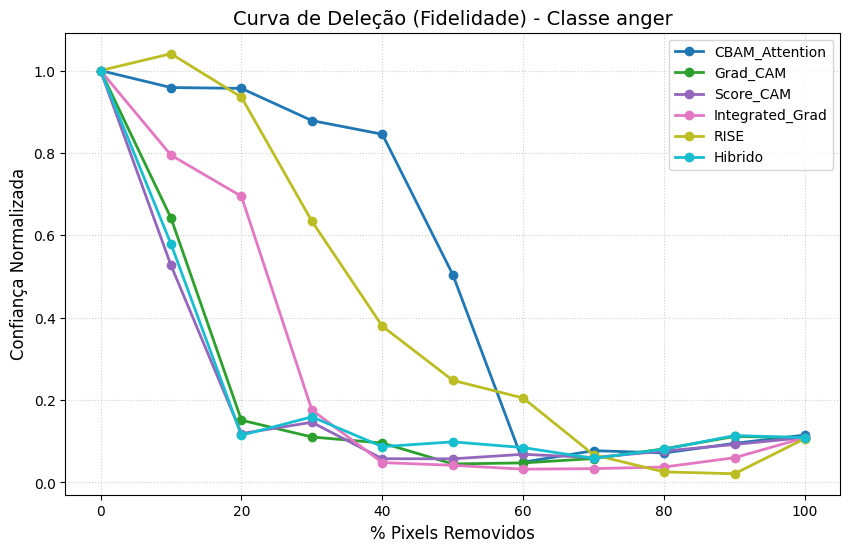

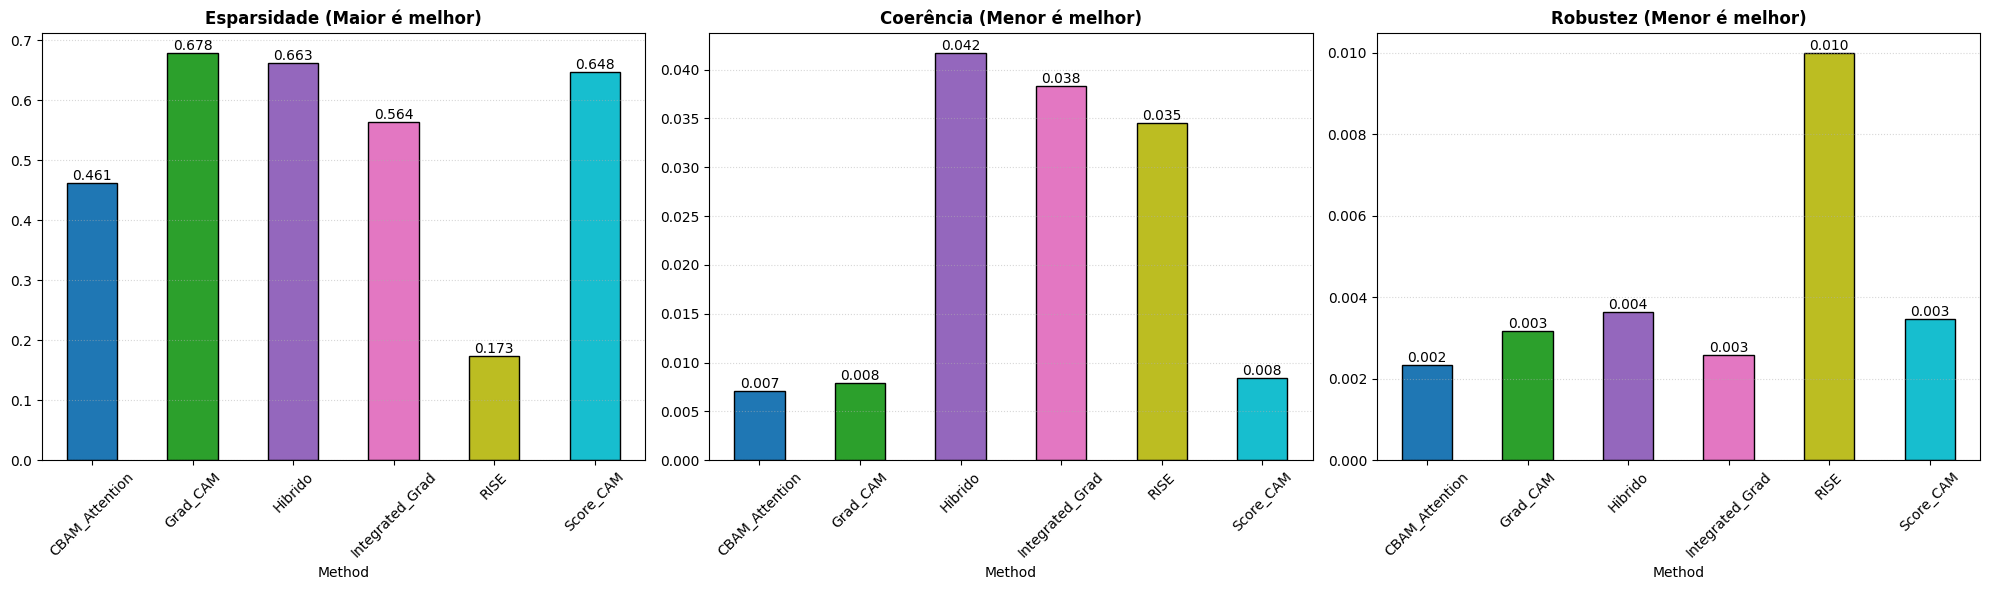

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import random
import tensorflow as tf
from scipy.stats import spearmanr
from tqdm.notebook import tqdm
from tensorflow.keras.models import Model

TARGET_CLASS = 'anger'
NUM_SAMPLES = 4
CONFIDENCE_THRESHOLD = 0.80
OUTPUT_DIR = 'avaliacao_anger_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Iniciando avaliação para {NUM_SAMPLES} imagens de '{TARGET_CLASS}' com confiança > {CONFIDENCE_THRESHOLD:.0%}...")


def preprocess_input_vggface_manual(x):
    x_temp = x.copy().astype('float32')
    if np.max(x_temp) <= 1.5: x_temp *= 255.0
    if x_temp.ndim == 2: x_temp = np.stack((x_temp,)*3, axis=-1)
    elif x_temp.ndim == 3 and x_temp.shape[-1] == 1: x_temp = np.concatenate([x_temp]*3, axis=-1)
    x_temp = x_temp[..., ::-1]
    x_temp[..., 0] -= 91.4953; x_temp[..., 1] -= 103.8827; x_temp[..., 2] -= 131.0912
    return x_temp

def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if len(layer.output.shape) == 4 and 'spatial' not in layer.name and 'reshape' not in layer.name:
            return layer.name
    return None

def generate_xai_map(method, model, img_batch, pred_idx, last_conv):
    if method == 'CBAM_Attention':
        try:
            aux = Model(inputs=model.input, outputs=model.get_layer('spatial_attention_map').output)
            return np.squeeze(aux.predict(img_batch, verbose=0))
        except: return np.zeros((7,7))
        
    elif method == 'Grad_CAM':
        grad_model = Model([model.inputs], [model.get_layer(last_conv).output, model.output])
        with tf.GradientTape() as tape:
            conv_out, preds = grad_model(img_batch)
            loss = preds[:, pred_idx]
        grads = tape.gradient(loss, conv_out)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
        return tf.squeeze(tf.maximum(heatmap, 0)).numpy()
        
    elif method == 'Score_CAM':
        act_model = Model(inputs=model.input, outputs=model.get_layer(last_conv).output)
        acts = act_model.predict(img_batch, verbose=0)[0]
        acts_res = tf.image.resize(acts, (224, 224)).numpy()
        mins, maxs = acts_res.min(axis=(0,1), keepdims=True), acts_res.max(axis=(0,1), keepdims=True)
        acts_norm = (acts_res - mins) / (maxs - mins + 1e-7)
        top_ch = np.argsort(np.var(acts, axis=(0,1)))[::-1][:32]
        masked = np.array([img_batch[0] * acts_norm[:, :, ch][..., None] for ch in top_ch])
        preds = model.predict(masked, verbose=0)
        probs = tf.nn.softmax(preds, axis=1).numpy()
        weights = probs[:, pred_idx]
        cam = np.sum([w * acts_norm[:, :, ch] for w, ch in zip(weights, top_ch)], axis=0)
        return np.maximum(cam, 0)

    elif method == 'Integrated_Grad':
        baseline = tf.zeros_like(img_batch)
        steps = 20
        inputs = [baseline + (float(i)/steps)*(img_batch-baseline) for i in range(steps+1)]
        inputs = tf.concat(inputs, axis=0)
        grads = []
        for i in range(0, len(inputs), 16):
            batch = inputs[i:i+16]
            with tf.GradientTape() as tape:
                tape.watch(batch)
                preds = model(batch)
                loss = preds[:, pred_idx]
            grads.append(tape.gradient(loss, batch))
        grads = tf.concat(grads, axis=0)
        avg_grads = tf.reduce_mean(grads, axis=0)
        return tf.reduce_sum(tf.abs((img_batch - baseline) * avg_grads), axis=-1)[0].numpy()

    elif method == 'RISE':
        n_masks = 200; p = 0.1; s = 8; h, w = 224, 224
        masks_low = np.random.choice([0, 1], size=(n_masks, h//s, w//s), p=[1-p, p])
        masks_up = np.array([cv2.resize(m.astype('float32'), (w, h)) for m in masks_low])
        masked = img_batch * masks_up[:, :, :, None]
        preds_list = []
        for i in range(0, n_masks, 32):
            p_batch = model.predict(masked[i:i+32], verbose=0)
            preds_list.append(tf.nn.softmax(p_batch, axis=1).numpy())
        preds = np.vstack(preds_list)
        return np.sum(preds[:, pred_idx][:, None, None] * masks_up, axis=0)
    
    return np.zeros((224,224))

def calc_metrics(model, img_batch, heatmap, pred_idx, method_name, last_conv):
    if heatmap.ndim < 2: heatmap = np.zeros((224,224))
    hm_full = cv2.resize(heatmap, (224, 224))
    h_min, h_max = hm_full.min(), hm_full.max()
    hm_norm = (hm_full - h_min) / (h_max - h_min + 1e-8)
    
    flat = np.abs(hm_norm.flatten())
    flat /= (np.sum(flat) + 1e-7)
    flat = np.sort(flat)
    n = len(flat)
    index = np.arange(1, n + 1)
    gini = (np.sum((2 * index - n - 1) * flat)) / (n * np.sum(flat) + 1e-7)
    
    tv = (np.sum(np.abs(np.diff(hm_norm, axis=0))) + np.sum(np.abs(np.diff(hm_norm, axis=1)))) / hm_norm.size

    noise = np.random.normal(0, 10.0, img_batch.shape).astype('float32')
    
    if method_name == 'Hibrido':
        ig_n = generate_xai_map('Integrated_Grad', model, img_batch+noise, pred_idx, last_conv)
        gc_n = generate_xai_map('Grad_CAM', model, img_batch+noise, pred_idx, last_conv)
        def norm(m): r = cv2.resize(m, (224,224)); return (r-r.min())/(r.max()-r.min()+1e-8)
        hm_noise = (norm(ig_n)**0.5) * (norm(gc_n)**0.5)
    else:
        hm_noise = generate_xai_map(method_name, model, img_batch+noise, pred_idx, last_conv)
        
    hm_noise = cv2.resize(hm_noise, (224, 224))
    hm_noise = (hm_noise - hm_noise.min()) / (hm_noise.max() - hm_noise.min() + 1e-8)
    
    robustness = np.linalg.norm(hm_norm - hm_noise) / (np.linalg.norm(noise) + 1e-7)

    steps = 10
    flat_indices = np.argsort(hm_norm.flatten())[::-1]
    scores = []
    img_copy = img_batch[0].copy()
    pixel_step = len(flat_indices) // steps
    
    p0 = tf.nn.softmax(model.predict(np.expand_dims(img_copy, 0), verbose=0), axis=1).numpy()[0][pred_idx]
    scores.append(p0)
    
    for i in range(steps):
        indices = flat_indices[i*pixel_step : (i+1)*pixel_step]
        unraveled = np.unravel_index(indices, (224, 224))
        img_copy[unraveled] = 0.0
        p = tf.nn.softmax(model.predict(np.expand_dims(img_copy, 0), verbose=0), axis=1).numpy()[0][pred_idx]
        scores.append(p)
        
    deletion_curve = np.array(scores) / (scores[0] + 1e-7)
    
    return gini, tv, robustness, deletion_curve


last_conv = get_last_conv_layer(model)
target_label_idx = [k for k,v in emotion_dict.items() if v == TARGET_CLASS][0]
selected_indices = []

all_idx = list(range(len(x_test)))

for i in all_idx:
    if len(selected_indices) >= NUM_SAMPLES: break
    if np.argmax(y_test[i]) != target_label_idx: continue
    
    img_raw = x_test[i]
    img_big = cv2.resize(img_raw, (224, 224), interpolation=cv2.INTER_CUBIC)
    img_rgb = np.stack((img_big,)*3, axis=-1)
    img_inp = preprocess_input_vggface_manual(img_rgb)
    img_batch = np.expand_dims(img_inp, axis=0)
    
    preds = model.predict(img_batch, verbose=0)
    probs = tf.nn.softmax(preds, axis=1).numpy()
    pred_idx = np.argmax(probs[0])
    
    if pred_idx == target_label_idx and probs[0][pred_idx] >= CONFIDENCE_THRESHOLD:
        selected_indices.append(i)
        print(f"Imagem selecionada: {i} (Conf: {probs[0][pred_idx]:.2%})")

methods = ['CBAM_Attention', 'Grad_CAM', 'Score_CAM', 'Integrated_Grad', 'RISE', 'Hibrido']
results_data = []
deletion_curves = {m: [] for m in methods}

for idx in tqdm(selected_indices, desc="Processando Imagens"):
    img_raw = x_test[idx]
    img_big = cv2.resize(img_raw, (224, 224), interpolation=cv2.INTER_CUBIC)
    img_rgb = np.stack((img_big,)*3, axis=-1)
    img_inp = preprocess_input_vggface_manual(img_rgb)
    img_batch = np.expand_dims(img_inp, axis=0)
    pred_idx = target_label_idx
    
    maps = {}
    maps['CBAM_Attention'] = generate_xai_map('CBAM_Attention', model, img_batch, pred_idx, last_conv)
    maps['Grad_CAM'] = generate_xai_map('Grad_CAM', model, img_batch, pred_idx, last_conv)
    maps['Score_CAM'] = generate_xai_map('Score_CAM', model, img_batch, pred_idx, last_conv)
    maps['Integrated_Grad'] = generate_xai_map('Integrated_Grad', model, img_batch, pred_idx, last_conv)
    maps['RISE'] = generate_xai_map('RISE', model, img_batch, pred_idx, last_conv)
    
    def norm(m): r = cv2.resize(m, (224, 224)); return (r - r.min()) / (r.max() - r.min() + 1e-8)
    maps['Hibrido'] = (norm(maps['Integrated_Grad']) ** 0.5) * (norm(maps['Grad_CAM']) ** 0.5)
    
    for m_name in methods:
        gini, tv, rob, curve = calc_metrics(model, img_batch, maps[m_name], pred_idx, m_name, last_conv)
        
        results_data.append({
            'Image_Idx': idx,
            'Method': m_name,
            'Sparsity_Gini': gini,
            'Coherence_TV': tv,
            'Robustness': rob,
            'Deletion_AUC': np.trapz(curve, dx=0.1)
        })
        deletion_curves[m_name].append(curve)

df = pd.DataFrame(results_data)
df.to_csv(f"{OUTPUT_DIR}/avaliacao_anger_metrics.csv", index=False)
print(f"Dados salvos em {OUTPUT_DIR}/avaliacao_anger_metrics.csv")

df_mean = df.groupby('Method').mean(numeric_only=True)

plt.figure(figsize=(10, 6))
x_axis = np.linspace(0, 100, 11)
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

for i, method in enumerate(methods):
    mean_curve = np.mean(deletion_curves[method], axis=0)
    plt.plot(x_axis, mean_curve, marker='o', label=method, color=colors[i], linewidth=2)

plt.title(f'Curva de Deleção (Fidelidade) - Classe {TARGET_CLASS}', fontsize=14)
plt.xlabel('% Pixels Removidos', fontsize=12)
plt.ylabel('Confiança Normalizada', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(f"{OUTPUT_DIR}/chart_deletion_line.png")
plt.show()

metrics_bar = [
    ('Sparsity_Gini', 'Esparsidade (Maior é melhor)'),
    ('Coherence_TV', 'Coerência (Menor é melhor)'),
    ('Robustness', 'Robustez (Menor é melhor)')
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (metric, title) in enumerate(metrics_bar):
    ax = axes[i]
    df_mean[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='black', rot=45)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width()/2, p.get_height()),
                   ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/charts_metrics_bars.png")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import os
import random
import tensorflow as tf
from tensorflow.keras.models import Model
from tqdm.notebook import tqdm

TARGET_EMOTION = 'happiness'
CONFIDENCE_THRESHOLD = 1
OUTPUT_DIR = f'xai_full_comparison_{TARGET_EMOTION}'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Configuração: Buscando imagem de '{TARGET_EMOTION}' com confiança > {CONFIDENCE_THRESHOLD:.0%}...")

def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if len(layer.output.shape) == 4 and 'spatial' not in layer.name and 'reshape' not in layer.name:
            return layer.name
    return None

def preprocess_input_vggface_manual(x):
    x_temp = x.copy().astype('float32')
    if np.max(x_temp) <= 1.5: x_temp *= 255.0
    if x_temp.ndim == 2: x_temp = np.stack((x_temp,)*3, axis=-1)
    elif x_temp.ndim == 3 and x_temp.shape[-1] == 1: x_temp = np.concatenate([x_temp]*3, axis=-1)
    x_temp = x_temp[..., ::-1] # BGR
    x_temp[..., 0] -= 91.4953; x_temp[..., 1] -= 103.8827; x_temp[..., 2] -= 131.0912
    return x_temp

def get_cbam_map(model, img_batch):
    try:
        aux_model = Model(inputs=model.input, outputs=model.get_layer('spatial_attention_map').output)
        return np.squeeze(aux_model.predict(img_batch, verbose=0))
    except: return np.zeros((7,7))

def get_gradcam(model, img_batch, class_idx, layer_name):
    grad_model = Model([model.inputs], [model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch)
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    return tf.squeeze(tf.maximum(heatmap, 0)).numpy()

def get_scorecam(model, img_batch, class_idx, layer_name, max_n=32):
    act_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    acts = act_model.predict(img_batch, verbose=0)[0]
    acts_resized = tf.image.resize(acts, (224, 224)).numpy()
    mins, maxs = acts_resized.min(axis=(0,1), keepdims=True), acts_resized.max(axis=(0,1), keepdims=True)
    acts_norm = (acts_resized - mins) / (maxs - mins + 1e-7)
    
    top_channels = np.argsort(np.var(acts, axis=(0,1)))[::-1][:max_n]
    masked_inputs = np.array([img_batch[0] * acts_norm[:, :, ch][..., None] for ch in top_channels])
    
    preds = model.predict(masked_inputs, verbose=0)
    probs = tf.nn.softmax(preds, axis=1).numpy()
    weights = probs[:, class_idx]
    
    cam = np.sum([w * acts_norm[:, :, ch] for w, ch in zip(weights, top_channels)], axis=0)
    return np.maximum(cam, 0)

def get_integrated_gradients(model, img_batch, class_idx, steps=20):
    baseline = tf.zeros_like(img_batch)
    inputs_interp = [baseline + (float(i)/steps)*(img_batch-baseline) for i in range(steps+1)]
    inputs_interp = tf.concat(inputs_interp, axis=0)
    
    grads = []
    for i in range(0, len(inputs_interp), 16):
        batch = inputs_interp[i:i+16]
        with tf.GradientTape() as tape:
            tape.watch(batch)
            preds = model(batch)
            loss = preds[:, class_idx]
        grads.append(tape.gradient(loss, batch))
    
    grads = tf.concat(grads, axis=0)
    avg_grads = tf.reduce_mean(grads, axis=0)
    return tf.reduce_sum(tf.abs((img_batch - baseline) * avg_grads), axis=-1)[0].numpy()

def get_rise(model, img_batch, class_idx, n_masks=200, p=0.1, s=8):
    h, w = 224, 224
    masks_low = np.random.choice([0, 1], size=(n_masks, h//s, w//s), p=[1-p, p])
    masks_up = np.array([cv2.resize(m.astype('float32'), (w, h)) for m in masks_low])
    
    masked = img_batch * masks_up[:, :, :, None]
    preds_list = []
    for i in range(0, n_masks, 32):
        p_batch = model.predict(masked[i:i+32], verbose=0)
        preds_list.append(tf.nn.softmax(p_batch, axis=1).numpy())
    preds = np.vstack(preds_list)
    return np.sum(preds[:, class_idx][:, None, None] * masks_up, axis=0)

Configuração: Buscando imagem de 'happiness' com confiança > 100%...


Buscando imagem específica: 'fer0028735.png'...
Imagem encontrada no índice 4139!
Caminho completo: /kaggle/input/fer2013plus/fer2013plus/fer2013/test/happiness/fer0028735.png
Label Real: happiness
Predição Modelo: happiness (100.00%)
Gerando heatmaps...


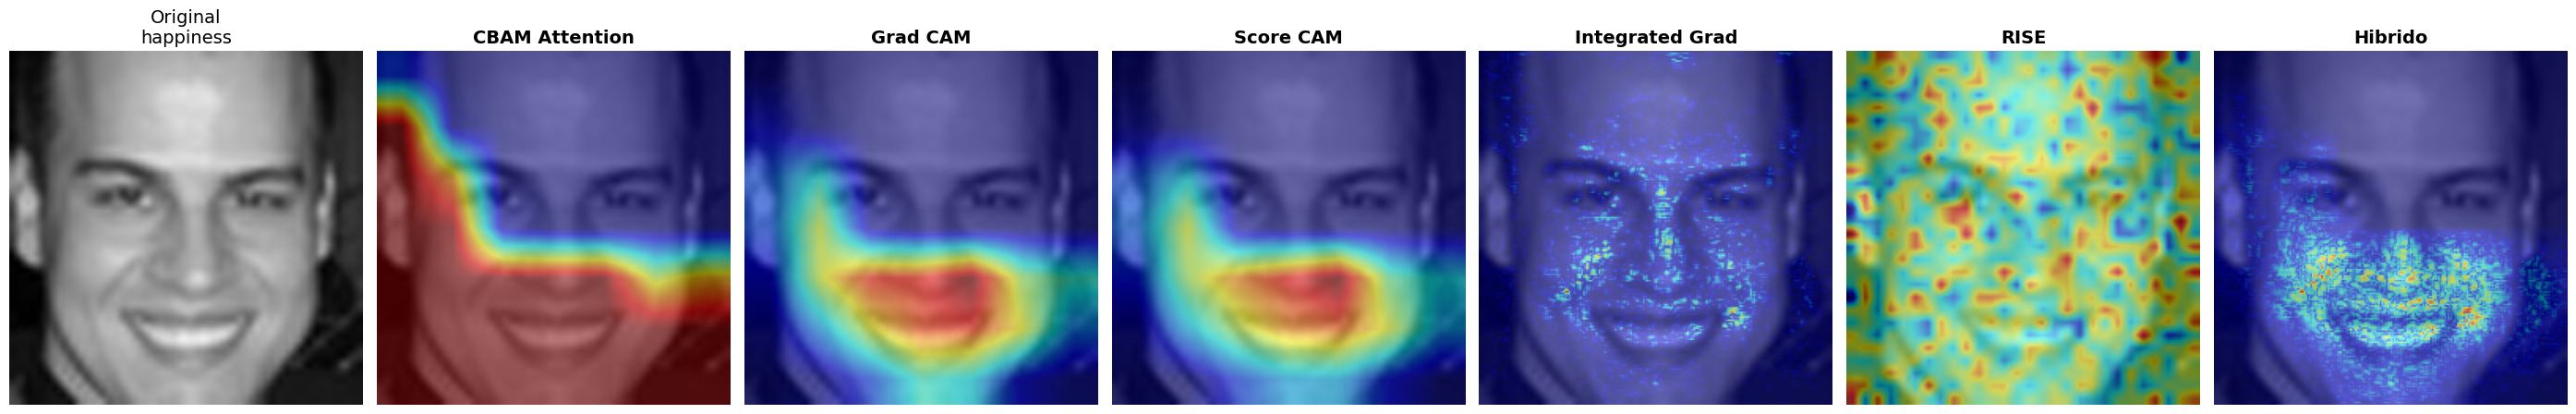

Imagens salvas em: /kaggle/working/xai_single_image_result


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.models import Model

TARGET_FILENAME = "fer0028735.png"
OUTPUT_DIR = 'xai_single_image_result'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Buscando imagem específica: '{TARGET_FILENAME}'...")

target_idx = -1
found_path = ""

for i, path in enumerate(filepaths):
    if TARGET_FILENAME in path:
        target_idx = i
        found_path = path
        break

if target_idx == -1:
    raise ValueError(f"ERRO: A imagem '{TARGET_FILENAME}' não foi encontrada na lista de arquivos carregados.")

print(f"Imagem encontrada no índice {target_idx}!")
print(f"Caminho completo: {found_path}")


img_raw = x_test[target_idx]
true_label_idx = np.argmax(y_test[target_idx])
emotion_real = emotion_dict[true_label_idx]

img_big = cv2.resize(img_raw, (224, 224), interpolation=cv2.INTER_CUBIC)
img_rgb = np.stack((img_big,)*3, axis=-1)
img_input = preprocess_input_vggface_manual(img_rgb)
img_batch = np.expand_dims(img_input, axis=0)

# Predição do Modelo
logits = model.predict(img_batch, verbose=0)
probs = tf.nn.softmax(logits, axis=1).numpy()
pred_idx = np.argmax(probs[0])
conf = probs[0][pred_idx]
emotion_pred = emotion_dict[pred_idx]

print(f"Label Real: {emotion_real}")
print(f"Predição Modelo: {emotion_pred} ({conf:.2%})")

print("Gerando heatmaps...")

last_conv = get_last_conv_layer(model)

maps = {
    'CBAM_Attention': get_cbam_map(model, img_batch),
    'Grad_CAM': get_gradcam(model, img_batch, pred_idx, last_conv),
    'Score_CAM': get_scorecam(model, img_batch, pred_idx, last_conv),
    'Integrated_Grad': get_integrated_gradients(model, img_batch, pred_idx, steps=20),
    'RISE': get_rise(model, img_batch, pred_idx, n_masks=200)
}

def norm_math(m):
    r = cv2.resize(m, (224, 224))
    return (r - r.min()) / (r.max() - r.min() + 1e-8)

maps['Hibrido'] = (norm_math(maps['Integrated_Grad']) ** 0.5) * (norm_math(maps['Grad_CAM']) ** 0.5)

cols = len(maps) + 1
fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 5))

axes[0].imshow(img_rgb.astype('uint8'))
axes[0].set_title(f"Original\n{emotion_real}", fontsize=14)
axes[0].axis('off')
cv2.imwrite(f"{OUTPUT_DIR}/0_original.png", cv2.cvtColor(img_rgb.astype('uint8'), cv2.COLOR_RGB2BGR))

sorted_keys = ['CBAM_Attention', 'Grad_CAM', 'Score_CAM', 'Integrated_Grad', 'RISE', 'Hibrido']

for i, name in enumerate(sorted_keys):
    heatmap = maps[name]
    if heatmap.ndim < 2: heatmap = np.zeros((224,224))
    
    hm_res = cv2.resize(heatmap, (224, 224))
    hm_min, hm_max = hm_res.min(), hm_res.max()
    if (hm_max - hm_min) > 1e-7:
        hm_norm = (hm_res - hm_min) / (hm_max - hm_min)
    else:
        hm_norm = hm_res
        
    hm_uint8 = np.uint8(255 * hm_norm)
    hm_color = cv2.applyColorMap(hm_uint8, cv2.COLORMAP_JET)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    
    overlay = cv2.addWeighted(img_rgb.astype('uint8'), 0.5, hm_color, 0.5, 0)
    
    ax = axes[i+1]
    ax.imshow(overlay)
    ax.set_title(name.replace('_', ' '), fontsize=14, fontweight='bold')
    ax.axis('off')
    
    cv2.imwrite(f"{OUTPUT_DIR}/{name}.png", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

plt.tight_layout()
plt.show()
print(f"Imagens salvas em: {os.path.abspath(OUTPUT_DIR)}")

In [ ]:
def preprocess_input_vggface_manual(x):
    x_temp = x.copy().astype('float32')
    if np.max(x_temp) > 1.5: pass
    else: x_temp *= 255.0
    
    if x_temp.ndim == 2:
        x_temp = np.stack((x_temp,)*3, axis=-1)
    elif x_temp.ndim == 3 and x_temp.shape[-1] == 1:
        x_temp = np.concatenate([x_temp]*3, axis=-1)
        
    x_temp = x_temp[..., ::-1]
    x_temp[..., 0] -= 91.4953; x_temp[..., 1] -= 103.8827; x_temp[..., 2] -= 131.0912
    return x_temp

def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        try:
            shape = layer.output.shape
            if len(shape) == 4:
                if 'spatial' not in layer.name and 'reshape' not in layer.name:
                    return layer.name
        except AttributeError:
            continue
    return None

def get_cbam_map(model, img_batch):
    try:
        aux_model = Model(inputs=model.input, outputs=model.get_layer('spatial_attention_map').output)
        heatmap = aux_model.predict(img_batch, verbose=0)
        return np.squeeze(heatmap)
    except:
        return np.zeros((7,7))

def get_gradcam(model, img_batch, class_idx, layer_name):
    grad_model = Model([model.inputs], [model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch)
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    return tf.squeeze(tf.maximum(heatmap, 0)).numpy()

def get_scorecam(model, img_batch, class_idx, layer_name, max_n=16):
    act_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    acts = act_model.predict(img_batch, verbose=0)[0]
    acts_resized = tf.image.resize(acts, (224, 224)).numpy()
    
    mins, maxs = acts_resized.min(axis=(0,1), keepdims=True), acts_resized.max(axis=(0,1), keepdims=True)
    acts_norm = (acts_resized - mins) / (maxs - mins + 1e-7)
    
    top_channels = np.argsort(np.var(acts, axis=(0,1)))[::-1][:max_n]
    
    masked_inputs = np.array([img_batch[0] * acts_norm[:, :, ch][..., None] for ch in top_channels])
    preds = model.predict(masked_inputs, verbose=0)
    weights = preds[:, class_idx]
    
    cam = np.sum([w * acts_norm[:, :, ch] for w, ch in zip(weights, top_channels)], axis=0)
    return np.maximum(cam, 0)

def get_integrated_gradients(model, img_batch, class_idx, steps=10):
    baseline = tf.zeros_like(img_batch)
    inputs_interp = [baseline + (float(i)/steps)*(img_batch-baseline) for i in range(steps+1)]
    inputs_interp = tf.concat(inputs_interp, axis=0)
    
    grads = []
    chunk_size = 8
    for i in range(0, len(inputs_interp), chunk_size):
        batch = inputs_interp[i:i+chunk_size]
        with tf.GradientTape() as tape:
            tape.watch(batch)
            preds = model(batch)
            loss = preds[:, class_idx]
        grads.append(tape.gradient(loss, batch))
    
    grads = tf.concat(grads, axis=0)
    avg_grads = tf.reduce_mean(grads, axis=0)
    return tf.reduce_sum(tf.abs((img_batch - baseline) * avg_grads), axis=-1)[0].numpy()

def get_rise(model, img_batch, class_idx, n_masks=200, p=0.1, s=8):
    h, w = 224, 224
    masks_low = np.random.choice([0, 1], size=(n_masks, h//s, w//s), p=[1-p, p])
    masks_up = np.array([cv2.resize(m.astype('float32'), (w, h)) for m in masks_low])
    
    masked = img_batch * masks_up[:, :, :, None]
    preds_list = []
    for i in range(0, n_masks, 32):
        preds_list.append(model.predict(masked[i:i+32], verbose=0))
    preds = np.vstack(preds_list)
    
    return np.sum(preds[:, class_idx][:, None, None] * masks_up, axis=0)

In [ ]:
import matplotlib.pyplot as plt
import random

OUTPUT_DIR = 'xai_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

last_conv = get_last_conv_layer(model)
print(f"Camada convolucional alvo encontrada: {last_conv}")

if not last_conv:
    print("ERRO CRÍTICO: Não foi possível encontrar a última camada convolucional.")

if 'selected_samples' not in locals() or len(selected_samples) == 0:
    print("Buscando exemplos preditos corretamente...")
    selected_samples = []
    target_count = 4
    checked_indices = list(range(len(x_test)))
    random.shuffle(checked_indices)

    for i in checked_indices:
        if len(selected_samples) >= target_count: break
        
        img_raw = x_test[i]
        img_big = cv2.resize(img_raw, (224, 224), interpolation=cv2.INTER_CUBIC)
        img_rgb = np.stack((img_big,)*3, axis=-1)
        img_input = preprocess_input_vggface_manual(img_rgb)
        img_batch = np.expand_dims(img_input, axis=0)
        
        preds = model.predict(img_batch, verbose=0)
        pred_idx = np.argmax(preds[0])
        true_idx = np.argmax(y_test[i])
        
        if pred_idx == true_idx:
            curr_emotions = [s['label'] for s in selected_samples]
            label = emotion_dict[true_idx]
            if label not in curr_emotions or len(curr_emotions) >= 4:
                selected_samples.append({
                    'id': i, 'img_rgb': img_rgb, 'batch': img_batch,
                    'label': label, 'pred_idx': pred_idx, 'prob': preds[0][pred_idx]
                })
                print(f"-> Selecionado: Index {i} | Emoção: {label} ({preds[0][pred_idx]:.2%})")

for sample in selected_samples:
    lbl = sample['label']
    print(f"\n--- Gerando XAI para: {lbl} ---")
    
    maps = {
        'CBAM_Attention': get_cbam_map(model, sample['batch']),
        'Grad_CAM': get_gradcam(model, sample['batch'], sample['pred_idx'], last_conv),
        'Score_CAM': get_scorecam(model, sample['batch'], sample['pred_idx'], last_conv),
        'Integrated_Grad': get_integrated_gradients(model, sample['batch'], sample['pred_idx']),
        'RISE': get_rise(model, sample['batch'], sample['pred_idx'])
    }
    
    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    
    axes[0].imshow(sample['img_rgb'].astype('uint8'))
    axes[0].set_title(f"Original: {lbl}")
    axes[0].axis('off')
    cv2.imwrite(f"{OUTPUT_DIR}/{lbl}_original.png", cv2.cvtColor(sample['img_rgb'].astype('uint8'), cv2.COLOR_RGB2BGR))
    
    for i, (name, heatmap) in enumerate(maps.items()):
        if heatmap.ndim < 2: heatmap = np.zeros((7,7))
            
        heatmap_res = cv2.resize(heatmap, (224, 224))
        h_min, h_max = heatmap_res.min(), heatmap_res.max()
        if (h_max - h_min) > 1e-7:
            heatmap_norm = (heatmap_res - h_min) / (h_max - h_min)
        else:
            heatmap_norm = heatmap_res
            
        heatmap_uint8 = np.uint8(255 * heatmap_norm)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        
        overlay = cv2.addWeighted(sample['img_rgb'].astype('uint8'), 0.5, heatmap_color, 0.5, 0)
        
        axes[i+1].imshow(overlay)
        axes[i+1].set_title(name)
        axes[i+1].axis('off')
        
        fname = f"{OUTPUT_DIR}/{lbl}_pred_{lbl}_{name}.png"
        cv2.imwrite(fname, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    
    plt.tight_layout()
    plt.show()

print(f"\nImagens salvas em: {os.path.abspath(OUTPUT_DIR)}")

In [ ]:
from scipy.stats import spearmanr

def metric_sparsity_gini(heatmap):
    """Calcula o Índice de Gini (Esparcidade). Quanto mais próximo de 1, mais esparso."""
    flattened = np.abs(heatmap.flatten())
    flattened /= (np.sum(flattened) + 1e-7)
    flattened = np.sort(flattened)
    n = len(flattened)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * flattened)) / (n * np.sum(flattened) + 1e-7)

def metric_coherence_tv(heatmap):
    """Calcula Total Variation (Coerência). Quanto menor, mais contínua."""
    diff_h = np.sum(np.abs(np.diff(heatmap, axis=0)))
    diff_w = np.sum(np.abs(np.diff(heatmap, axis=1)))
    return (diff_h + diff_w) / (heatmap.size)

def metric_deletion_auc(model, img_batch, heatmap, pred_idx, steps=10):
    """Calcula a Área Sob a Curva de Deleção (Faithfulness)."""
    h_min, h_max = heatmap.min(), heatmap.max()
    hm_norm = (heatmap - h_min) / (h_max - h_min + 1e-7)
    
    flat_indices = np.argsort(hm_norm.flatten())[::-1]
    
    scores = []
    img_copy = img_batch[0].copy()
    n_pixels = img_copy.shape[0] * img_copy.shape[1]
    step_size = n_pixels // steps
    
    pred_orig = model.predict(np.expand_dims(img_copy, 0), verbose=0)[0][pred_idx]
    scores.append(pred_orig)
    
    for i in range(steps):
        current_indices = flat_indices[i*step_size : (i+1)*step_size]
        unraveled = np.unravel_index(current_indices, (224, 224))
        img_copy[unraveled] = 0.0
        pred_new = model.predict(np.expand_dims(img_copy, 0), verbose=0)[0][pred_idx]
        scores.append(pred_new)
    
    scores = np.array(scores) / (scores[0] + 1e-7)
    auc = np.trapz(scores, dx=1.0/steps)
    return auc

def metric_robustness_consistency(model, img_batch, base_heatmap, method_name, pred_idx, last_conv):
    noise = np.random.normal(0, 10.0, img_batch.shape).astype('float32')
    noisy_img = img_batch + noise
    
    if method_name == 'CBAM_Attention':
        new_map = get_cbam_map(model, noisy_img)
    elif method_name == 'Grad_CAM':
        new_map = get_gradcam(model, noisy_img, pred_idx, last_conv)
    elif method_name == 'Score_CAM':
        new_map = get_scorecam(model, noisy_img, pred_idx, last_conv, max_n=32) 
    elif method_name == 'Integrated_Grad':
        new_map = get_integrated_gradients(model, noisy_img, pred_idx, steps=20)
    elif method_name == 'RISE':
        new_map = get_rise(model, noisy_img, pred_idx, n_masks=200)
    else:
        return np.nan, np.nan

    if new_map.ndim < 2: new_map = np.zeros((7,7))
    
    new_map = cv2.resize(new_map, (224, 224))
    base_map = cv2.resize(base_heatmap, (224, 224))
    
    try:
        corr, _ = spearmanr(base_map.flatten(), new_map.flatten())
        diff_map = np.linalg.norm(base_map - new_map)
        diff_input = np.linalg.norm(noise)
        sens = diff_map / (diff_input + 1e-7)
    except:
        corr, sens = 0, 0
    
    return corr, sens

print("Função de métricas atualizada para modo 'Full Power'.")

In [ ]:
print(f"Iniciando avaliação quantitativa em {len(selected_samples)} amostras...")
results = []

for sample in tqdm(selected_samples):
    batch = sample['batch']
    cls = sample['pred_idx']
    lbl = sample['label']
    
    maps = {
        'CBAM_Attention': get_cbam_map(model, batch),
        'Grad_CAM': get_gradcam(model, batch, cls, last_conv),
        'Score_CAM': get_scorecam(model, batch, cls, last_conv),
        'Integrated_Grad': get_integrated_gradients(model, batch, cls, steps=10),
        'RISE': get_rise(model, batch, cls, n_masks=100)
    }
    
    for method, heatmap in maps.items():
        if heatmap.ndim < 2: heatmap = np.zeros((7,7))
        heatmap_full = cv2.resize(heatmap, (224, 224))
        
        gini = metric_sparsity_gini(heatmap_full)
        tv = metric_coherence_tv(heatmap_full)
        auc = metric_deletion_auc(model, batch, heatmap_full, cls, steps=5)
        corr, sens = metric_robustness_consistency(model, batch, heatmap_full, method, cls, last_conv)
        
        results.append({
            'Sample': lbl,
            'Method': method,
            'Sparsity (Gini)': gini,
            'Coherence (TV)': tv,
            'Deletion (AUC)': auc,
            'Consistency (Corr)': corr,
            'Robustness (Sens)': sens
        })

df_results = pd.DataFrame(results)
print("Avaliação concluída.")

df_mean = df_results.groupby('Method').mean(numeric_only=True)

metrics_cfg = [
    ('Deletion (AUC)', 'Menor é melhor'),
    ('Consistency (Corr)', 'Maior é melhor'),
    ('Coherence (TV)', 'Menor é melhor'),
    ('Sparsity (Gini)', 'Maior é melhor'),
    ('Robustness (Sens)', 'Menor é melhor')
]

plt.figure(figsize=(20, 12))
plt.suptitle('Avaliação Comparativa dos Métodos de XAI', fontsize=16)

colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#D1A5E3']

for i, (metric, desc) in enumerate(metrics_cfg):
    if metric in df_mean.columns:
        valid_data = df_mean[metric].dropna()
        
        plt.subplot(2, 3, i+1)
        bars = plt.bar(valid_data.index, valid_data.values, color=colors[i], edgecolor='black')
        plt.title(metric, fontweight='bold')
        plt.ylabel('Score')
        plt.xticks(rotation=45)
        
        plt.text(0.5, -0.25, desc, ha='center', va='center', transform=plt.gca().transAxes, 
                 fontsize=9, style='italic', bbox=dict(facecolor='white', alpha=0.5))
        
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.3f}", ha='center', va='bottom')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f"{OUTPUT_DIR}/xai_evaluation_metrics.png")
plt.show()

print("\n--- Tabela de Resultados Médios ---")
display(df_mean)

In [ ]:
from scipy.stats import spearmanr
from tqdm.notebook import tqdm

CHARTS_DIR = 'xai_evaluation_charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

def calculate_gini(heatmap):
    """Esparsidade (Gini Index)."""
    flattened = np.abs(heatmap.flatten())
    flattened /= (np.sum(flattened) + 1e-7)
    flattened = np.sort(flattened)
    n = len(flattened)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * flattened)) / (n * np.sum(flattened) + 1e-7)

def calculate_coherence(heatmap):
    """Coerência Espacial (Total Variation)."""
    diff_h = np.sum(np.abs(np.diff(heatmap, axis=0)))
    diff_w = np.sum(np.abs(np.diff(heatmap, axis=1)))
    return (diff_h + diff_w) / (heatmap.size)

def calculate_deletion_curve(model, img_batch, heatmap, pred_idx, steps=10):
    """Retorna a lista de scores para a curva de deleção."""
    h_min, h_max = heatmap.min(), heatmap.max()
    hm_norm = (heatmap - h_min) / (h_max - h_min + 1e-7)
    flat_indices = np.argsort(hm_norm.flatten())[::-1]
    
    scores = []
    img_copy = img_batch[0].copy()
    n_pixels = img_copy.shape[0] * img_copy.shape[1]
    step_size = int(n_pixels / steps)
    
    pred_orig = model.predict(np.expand_dims(img_copy, 0), verbose=0)[0][pred_idx]
    scores.append(pred_orig)
    
    for i in range(steps):
        current_indices = flat_indices[i*step_size : (i+1)*step_size]
        unraveled = np.unravel_index(current_indices, (224, 224))
        img_copy[unraveled] = 0.0
        pred_new = model.predict(np.expand_dims(img_copy, 0), verbose=0)[0][pred_idx]
        scores.append(pred_new)
    
    return np.array(scores)

def calculate_robustness_consistency(model, img_batch, base_heatmap, method_name, pred_idx, last_conv):
    """Retorna (Consistência, Robustez)."""
    noise = np.random.normal(0, 10.0, img_batch.shape).astype('float32')
    noisy_img = img_batch + noise
    
    if method_name == 'CBAM_Attention': new_map = get_cbam_map(model, noisy_img)
    elif method_name == 'Grad_CAM': new_map = get_gradcam(model, noisy_img, pred_idx, last_conv)
    elif method_name == 'Score_CAM': new_map = get_scorecam(model, noisy_img, pred_idx, last_conv, max_n=16)
    else: return np.nan, np.nan # Pula

    if new_map.ndim < 2: new_map = np.zeros((7,7))
    new_map = cv2.resize(new_map, (224, 224))
    base_map = cv2.resize(base_heatmap, (224, 224))
    
    corr, _ = spearmanr(base_map.flatten(), new_map.flatten())
    
    diff_map = np.linalg.norm(base_map - new_map)
    diff_input = np.linalg.norm(noise)
    sens = diff_map / (diff_input + 1e-7)
    
    return corr, sens

methods = ['CBAM_Attention', 'Grad_CAM', 'Score_CAM', 'Integrated_Grad', 'RISE']

metrics_names = ['Sparsity', 'Coherence', 'Consistency', 'Robustness', 'Deletion']
results_agg = {m: {meth: [] for meth in methods} for m in metrics_names}

print(f"Calculando métricas para {len(selected_samples)} amostras...")

for sample in tqdm(selected_samples):
    batch = sample['batch']
    cls = sample['pred_idx']
    
    maps = {
        'CBAM_Attention': get_cbam_map(model, batch),
        'Grad_CAM': get_gradcam(model, batch, cls, last_conv),
        'Score_CAM': get_scorecam(model, batch, cls, last_conv),
        'Integrated_Grad': get_integrated_gradients(model, batch, cls, steps=15),
        'RISE': get_rise(model, batch, cls, n_masks=150)
    }
    
    for name, heatmap in maps.items():
        if heatmap.ndim < 2: heatmap = np.zeros((7,7))
        heatmap_full = cv2.resize(heatmap, (224, 224))
        
        results_agg['Sparsity'][name].append(calculate_gini(heatmap_full))
        
        results_agg['Coherence'][name].append(calculate_coherence(heatmap_full))
        
        curve = calculate_deletion_curve(model, batch, heatmap_full, cls, steps=10)
        results_agg['Deletion'][name].append(curve)
        
        c, r = calculate_robustness_consistency(model, batch, heatmap_full, name, cls, last_conv)
        if not np.nan:
            results_agg['Consistency'][name].append(c)
            results_agg['Robustness'][name].append(r)

print("Cálculos concluídos. Gerando gráficos...")

colors_dict = {
    'CBAM_Attention': '#9467bd',
    'Grad_CAM': '#1f77b4',      
    'RISE': '#ff7f0e',           
    'Score_CAM': '#2ca02c',      
    'Integrated_Grad': '#d62728' 
}

plt.figure(figsize=(10, 7))
steps = 10
x_axis = np.linspace(0, 100, steps + 1)

for name in methods:
    curves = np.array(results_agg['Deletion'][name])
    mean_curve = np.mean(curves, axis=0)
    
    plt.plot(x_axis, mean_curve, marker='o', linestyle='--', linewidth=2, 
             label=name, color=colors_dict[name])

plt.title('Teste de Deleção de Fidelidade (Faithfulness)', fontsize=15)
plt.xlabel('Porcentagem de Pixels Deletados (%)', fontsize=12)
plt.ylabel('Confiança do Modelo', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(f"{CHARTS_DIR}/chart_deletion_line.png")
plt.close()

bar_charts_config = [
    ('Sparsity', 'Esparsidade (Gini Index)', 'Maior = Mais Focado'),
    ('Coherence', 'Coerência Espacial (Total Variation)', 'Menor = Menos Ruído'),
    ('Consistency', 'Consistência Intra-classe', 'Maior = Mais Estável'),
    ('Robustness', 'Robustez (Sensibilidade)', 'Menor = Mais Robusto')
]

for metric_key, title, y_label in bar_charts_config:
    plt.figure(figsize=(10, 7))
    
    means = []
    names = []
    bar_colors = []
    
    for method in methods:
        data = results_agg[metric_key][method]
        data = [x for x in data if not np.isnan(x)]
        if data:
            val = np.mean(data)
            means.append(val)
            names.append(method)
            bar_colors.append(colors_dict[method])
    
    bars = plt.bar(names, means, color=bar_colors)
    
    plt.title(title, fontsize=16)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(means)*0.01), 
                 f"{yval:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"{CHARTS_DIR}/chart_{metric_key.lower()}_bar.png")
    plt.close()

print(f"\nTodos os gráficos foram salvos na pasta '{CHARTS_DIR}'!")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.stats import spearmanr

def diagnose_robustness(model, img_batch, method_name='Grad_CAM', noise_scale=10.0):
    print(f"--- Diagnóstico para {method_name} (Ruído: {noise_scale}) ---")
    
    last_conv = get_last_conv_layer(model)
    cls = np.argmax(model.predict(img_batch, verbose=0)[0])
    
    if method_name == 'Grad_CAM':
        base_map = get_gradcam(model, img_batch, cls, last_conv)
    elif method_name == 'Score_CAM':
        base_map = get_scorecam(model, img_batch, cls, last_conv)
    elif method_name == 'CBAM_Attention':
        base_map = get_cbam_map(model, img_batch)
    else:
        print("Método não suportado para este teste rápido.")
        return

    noise = np.random.normal(0, noise_scale, img_batch.shape).astype('float32')
    noisy_batch = img_batch + noise
    
    if method_name == 'Grad_CAM':
        noisy_map = get_gradcam(model, noisy_batch, cls, last_conv)
    elif method_name == 'Score_CAM':
        noisy_map = get_scorecam(model, noisy_batch, cls, last_conv)
    elif method_name == 'CBAM_Attention':
        noisy_map = get_cbam_map(model, noisy_batch)

    if base_map.ndim < 2: base_map = np.zeros((7,7))
    if noisy_map.ndim < 2: noisy_map = np.zeros((7,7))
    
    base_map = cv2.resize(base_map, (224, 224))
    noisy_map = cv2.resize(noisy_map, (224, 224))

    corr, _ = spearmanr(base_map.flatten(), noisy_map.flatten())
    diff = np.linalg.norm(base_map - noisy_map)
    sens = diff / (np.linalg.norm(noise) + 1e-7)

    print(f"Consistência (Correlação): {corr:.4f} (Ideal > 0.5)")
    print(f"Robustez (Sensibilidade):  {sens:.4f} (Ideal próximo de 0)")

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(base_map, cmap='viridis')
    plt.title("Mapa Original")
    plt.axis('off')
    
    disp_noise = noisy_batch[0].copy()
    disp_noise[..., 0] += 91.4953; disp_noise[..., 1] += 103.8827; disp_noise[..., 2] += 131.0912
    disp_noise = disp_noise[..., ::-1]
    disp_noise = np.clip(disp_noise, 0, 255).astype('uint8')
    
    plt.subplot(1, 3, 2)
    plt.imshow(disp_noise)
    plt.title("Imagem com Ruído")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(noisy_map, cmap='viridis')
    plt.title(f"Mapa c/ Ruído\nCorr: {corr:.2f}")
    plt.axis('off')
    
    plt.show()

if 'selected_samples' in locals() and len(selected_samples) > 0:
    test_batch = selected_samples[0]['batch']
    diagnose_robustness(model, test_batch, method_name='Grad_CAM', noise_scale=10.0)
    diagnose_robustness(model, test_batch, method_name='Score_CAM', noise_scale=10.0)
    diagnose_robustness(model, test_batch, method_name='CBAM_Attention', noise_scale=10.0)
else:
    print("Por favor, execute as células anteriores para carregar 'selected_samples'.")

In [ ]:
import os
BASE_DIR = 'xai_per_class_heatmaps_2'
DIR_CHARTS = 'xai_per_class_charts_2'
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(DIR_CHARTS, exist_ok=True)

CONFIDENCE_THRESHOLD = 30


def process_heatmap_visual(heatmap, img_rgb):
    if heatmap.ndim < 2: heatmap = np.zeros((224,224))
    hm_res = cv2.resize(heatmap, (224, 224))
    
    hm_min, hm_max = hm_res.min(), hm_res.max()
    if (hm_max - hm_min) > 1e-7:
        hm_norm = (hm_res - hm_min) / (hm_max - hm_min)
    else:
        hm_norm = hm_res
        
    hm_uint8 = np.uint8(255 * hm_norm)
    hm_color = cv2.applyColorMap(hm_uint8, cv2.COLORMAP_JET)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    
    overlay = cv2.addWeighted(img_rgb.astype('uint8'), 0.5, hm_color, 0.5, 0)
    return overlay, hm_res

print(f"Buscando exemplos com confiança > {CONFIDENCE_THRESHOLD:.0%}...")

class_samples = {}
found_classes = []
last_conv = get_last_conv_layer(model)

all_indices = list(range(len(x_test)))
random.shuffle(all_indices)

for i in tqdm(all_indices, desc="Varrendo dataset"):
    if len(found_classes) >= 8: break 
    
    img_raw = x_test[i]
    true_label_idx = np.argmax(y_test[i])
    emotion_name = emotion_dict[true_label_idx]
    
    if emotion_name in found_classes: continue

    img_big = cv2.resize(img_raw, (224, 224), interpolation=cv2.INTER_CUBIC)
    img_rgb = np.stack((img_big,)*3, axis=-1)
    img_input = preprocess_input_vggface_manual(img_rgb)
    img_batch = np.expand_dims(img_input, axis=0)
    
    preds = model.predict(img_batch, verbose=0)
    pred_idx = np.argmax(preds[0])
    conf = preds[0][pred_idx]
    
    if pred_idx == true_label_idx and conf >= CONFIDENCE_THRESHOLD:
        found_classes.append(emotion_name)
        class_samples[emotion_name] = {
            'img_rgb': img_rgb,
            'batch': img_batch,
            'idx': pred_idx,
            'conf': conf
        }

print("\n--- Gerando Heatmaps e Calculando Métricas Comparativas ---")

full_metrics = []

for emotion, data in tqdm(class_samples.items(), desc="Processando Classes"):
    batch = data['batch']
    cls = data['idx']
    img_rgb = data['img_rgb']
    
    gcam_raw = get_gradcam(model, batch, cls, last_conv)
    
    ig_raw = get_integrated_gradients(model, batch, cls, steps=20)
    
    def norm_math(m):
        r = cv2.resize(m, (224, 224))
        return (r - r.min()) / (r.max() - r.min() + 1e-8)
    
    hybrid_raw = (norm_math(ig_raw) ** 0.5) * (norm_math(gcam_raw) ** 0.5)
    
    maps_dict = {
        'Grad_CAM': gcam_raw,
        'Integrated_Grad': ig_raw,
        'Híbrido': hybrid_raw
    }
    
    emotion_dir = os.path.join(BASE_DIR, emotion)
    os.makedirs(emotion_dir, exist_ok=True)
    
    cv2.imwrite(os.path.join(emotion_dir, "0_original.png"), cv2.cvtColor(img_rgb.astype('uint8'), cv2.COLOR_RGB2BGR))
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img_rgb.astype('uint8'))
    axes[0].set_title(f"{emotion} ({data['conf']:.1%})")
    axes[0].axis('off')
    
    processed_maps = {}
    
    for i, (method_name, raw_map) in enumerate(maps_dict.items()):
        overlay, hm_resized = process_heatmap_visual(raw_map, img_rgb)
        processed_maps[method_name] = hm_resized
        
        # Mostra no painel
        axes[i+1].imshow(overlay)
        axes[i+1].set_title(method_name)
        axes[i+1].axis('off')
        
        # Salva arquivo individual
        save_name = f"{i+1}_{method_name}.png"
        cv2.imwrite(os.path.join(emotion_dir, save_name), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    
    plt.tight_layout()
    plt.show() # <--- MOSTRA A IMAGEM NO OUTPUT
    
    # --- C. CÁLCULO DE MÉTRICAS (PARA OS 3 MÉTODOS) ---
    # Ruído para teste de robustez (calculado uma vez por imagem)
    noise = np.random.normal(0, 10.0, batch.shape).astype('float32')
    
    for method_name, heatmap in processed_maps.items():
        # 1. Sparsity
        gini = metric_sparsity_gini(heatmap)
        # 2. Coherence
        tv = metric_coherence_tv(heatmap)
        # 3. Deletion (AUC)
        auc = metric_deletion_auc(model, batch, heatmap, cls, steps=10)
        
        # 4. Robustez (Simplificada: Recalcula o mapa ruidoso)
        # Nota: Para IG e Híbrido isso é lento, usamos passos reduzidos para o teste de ruído
        if method_name == 'Grad_CAM':
            noisy_map = get_gradcam(model, batch+noise, cls, last_conv)
        elif method_name == 'Integrated_Grad':
            noisy_map = get_integrated_gradients(model, batch+noise, cls, steps=10) # Menos steps
        else: # Híbrido
            n_g = get_gradcam(model, batch+noise, cls, last_conv)
            n_i = get_integrated_gradients(model, batch+noise, cls, steps=10)
            noisy_map = (norm_math(n_i)**0.5) * (norm_math(n_g)**0.5)
            
        noisy_map = cv2.resize(noisy_map, (224, 224))
        robustness = np.linalg.norm(heatmap - noisy_map) / (np.linalg.norm(noise) + 1e-7)
        
        full_metrics.append({
            'Emotion': emotion,
            'Method': method_name,
            'Sparsity (Gini)': gini,
            'Coherence (TV)': tv,
            'Deletion (AUC)': auc,
            'Robustness': robustness
        })

# --- 4. GERAÇÃO E EXIBIÇÃO DOS GRÁFICOS ---
if full_metrics:
    df = pd.DataFrame(full_metrics)
    
    # Configuração dos Gráficos
    metrics_config = [
        ('Sparsity (Gini)', 'Maior é melhor'),
        ('Deletion (AUC)', 'Menor é melhor'),
        ('Robustness', 'Menor é melhor'),
        ('Coherence (TV)', 'Menor é melhor')
    ]
    
    colors = {'Grad_CAM': '#1f77b4', 'Integrated_Grad': '#ff7f0e', 'Híbrido': '#2ca02c'}
    
    print("\n--- Comparação de Performance por Emoção ---")
    
    for metric, desc in metrics_config:
        plt.figure(figsize=(14, 6))
        
        # Pivota tabela para formato de barras agrupadas
        # Index=Emotion, Columns=Method, Values=Metric
        df_pivot = df.pivot(index='Emotion', columns='Method', values=metric)
        
        # Plota
        ax = df_pivot.plot(kind='bar', color=[colors.get(x, '#333') for x in df_pivot.columns], 
                          edgecolor='black', width=0.8, figsize=(14,6))
        
        plt.title(f"{metric} - Comparativo ({desc})", fontsize=15)
        plt.ylabel("Score")
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.legend(title='Método', bbox_to_anchor=(1.01, 1), loc='upper left')
        
        plt.tight_layout()
        
        save_path = f"{DIR_CHARTS}/compare_{metric.split()[0].lower()}.png"
        plt.savefig(save_path)
        plt.show()

    df.to_csv(f"{DIR_CHARTS}/full_comparison_results.csv", index=False)
    print("Tabela de dados brutos:")
    display(df.groupby('Method').mean(numeric_only=True))

else:
    print("Nenhum dado gerado para gráficos.")